In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

from sklearn.inspection import permutation_importance


In [2]:
df = pd.read_csv("deforestation_dataset.csv")

print(" Dataset Loaded")
print("Shape:", df.shape)
df.head()


 Dataset Loaded
Shape: (100, 14)


,Country,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
0,Indonesia,1971,560,8.929641,304,1635.715350,86759840,2551.805035,59.316366,3,9.426264,238,184,7.005531
1,Brazil,1927,3303,4.638441,341,1454.430241,83798502,2637.895996,14.211099,4,2.602618,418,78,20.044415
2,Russia,1961,4466,4.679313,298,1744.809660,41477592,2880.724721,44.869699,2,51.917315,186,49,22.747603
3,Australia,1967,3658,1.535528,285,1541.645853,71475964,2525.516988,10.824516,4,23.716328,190,2,22.701362
4,Australia,1987,2682,8.035841,450,1752.997736,16256333,608.916586,14.577190,4,21.424037,159,41,18.085869


In [3]:
df.info()
df.isnull().sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          100 non-null    object 
 1   Year                             100 non-null    int64  
 2   Forest_Loss_Area_km2             100 non-null    int64  
 3   Tree_Cover_Loss_percent          100 non-null    float64
 4   CO2_Emission_mt                  100 non-null    int64  
 5   Rainfall_mm                      100 non-null    float64
 6   Population                       100 non-null    int64  
 7   GDP_Billion_USD                  100 non-null    float64
 8   Agriculture_Land_Percent         100 non-null    float64
 9   Deforestation_Policy_Strictness  100 non-null    int64  
 10  Corruption_Index                 100 non-null    float64
 11  International_Aid_Million_USD    100 non-null    int64  
 12  Illegal_Lumbering_Incid

Country                            0
Year                               0
Forest_Loss_Area_km2               0
Tree_Cover_Loss_percent            0
CO2_Emission_mt                    0
Rainfall_mm                        0
Population                         0
GDP_Billion_USD                    0
Agriculture_Land_Percent           0
Deforestation_Policy_Strictness    0
Corruption_Index                   0
International_Aid_Million_USD      0
Illegal_Lumbering_Incidents        0
Protected_Areas_Percent            0
dtype: int64

In [4]:
median_loss = df["Forest_Loss_Area_km2"].median()
df["Deforestation_Risk"] = np.where(df["Forest_Loss_Area_km2"] > median_loss, 1, 0)

print(" Target created")
df["Deforestation_Risk"].value_counts()


 Target created


Deforestation_Risk
0    50
1    50
Name: count, dtype: int64

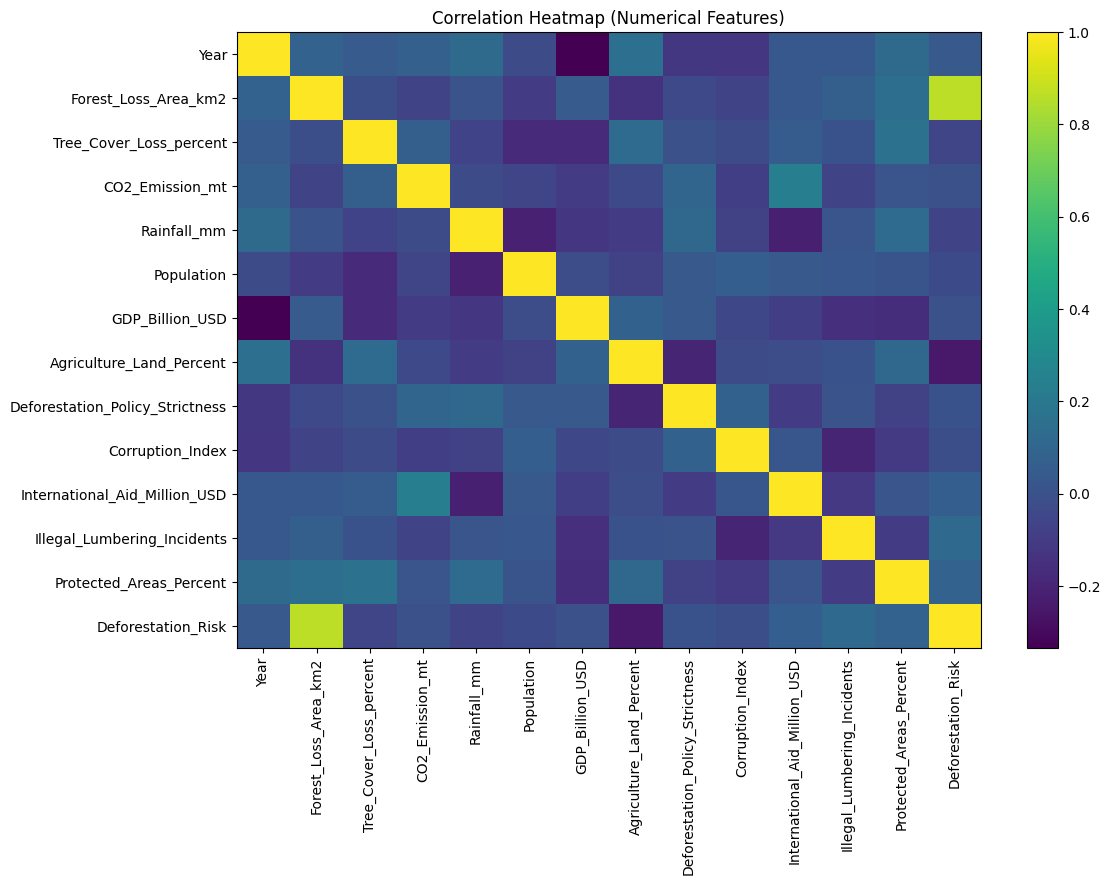

In [5]:
numeric_df = df.drop(columns=["Country"]).copy()

corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (Numerical Features)")
plt.colorbar()
plt.show()


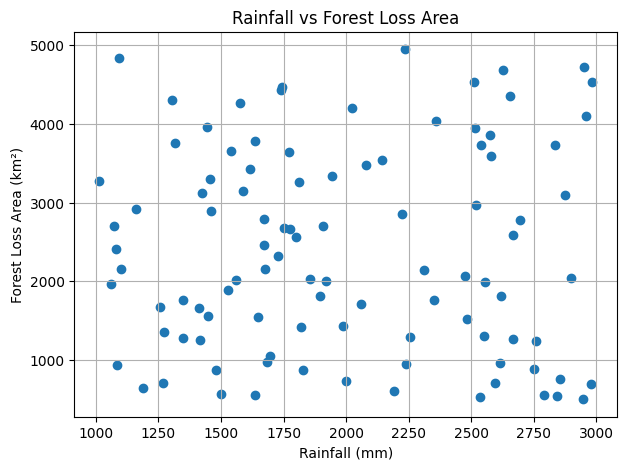

In [6]:
plt.figure(figsize=(7,5))
plt.scatter(df["Rainfall_mm"], df["Forest_Loss_Area_km2"])
plt.title("Rainfall vs Forest Loss Area")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Forest Loss Area (km²)")
plt.grid(True)
plt.show()


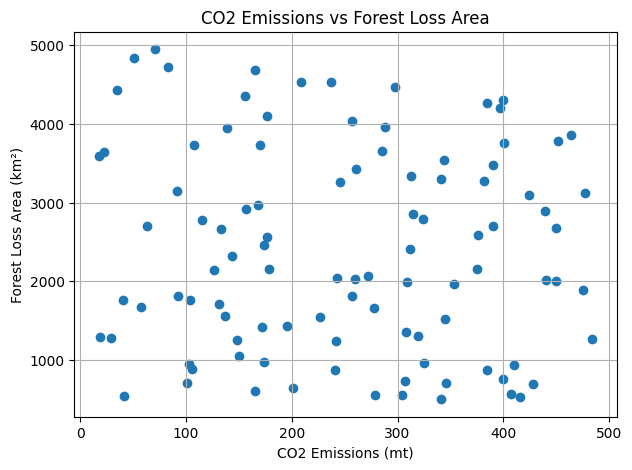

In [7]:
plt.figure(figsize=(7,5))
plt.scatter(df["CO2_Emission_mt"], df["Forest_Loss_Area_km2"])
plt.title("CO2 Emissions vs Forest Loss Area")
plt.xlabel("CO2 Emissions (mt)")
plt.ylabel("Forest Loss Area (km²)")
plt.grid(True)
plt.show()


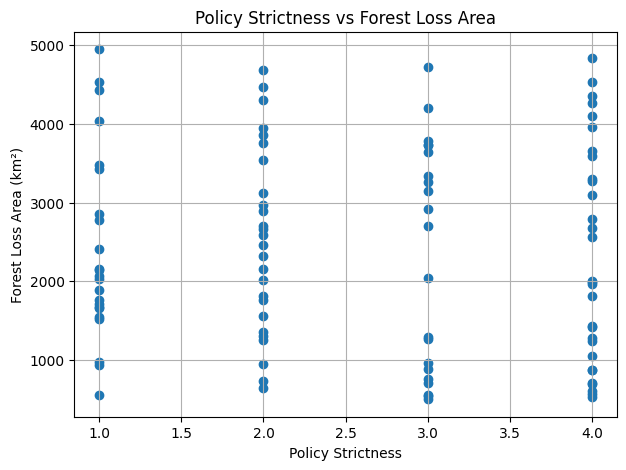

In [8]:
plt.figure(figsize=(7,5))
plt.scatter(df["Deforestation_Policy_Strictness"], df["Forest_Loss_Area_km2"])
plt.title("Policy Strictness vs Forest Loss Area")
plt.xlabel("Policy Strictness")
plt.ylabel("Forest Loss Area (km²)")
plt.grid(True)
plt.show()


In [9]:
feature_cols = [
    "Tree_Cover_Loss_percent",
    "CO2_Emission_mt",
    "Rainfall_mm",
    "Population",
    "GDP_Billion_USD",
    "Agriculture_Land_Percent",
    "Deforestation_Policy_Strictness",
    "Corruption_Index",
    "International_Aid_Million_USD",
    "Illegal_Lumbering_Incidents",
    "Protected_Areas_Percent"
]

risk_mean = df.groupby("Deforestation_Risk")[feature_cols].mean()
risk_mean.index = ["Low Risk", "High Risk"]
risk_mean


,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
Low Risk,5.713128,250.46,2022.917787,47637764.02,2528.802813,38.317365,2.58,47.578421,239.06,94.36,16.773921
High Risk,5.449520,249.10,1955.213562,45759093.04,2515.719985,31.081979,2.58,46.907501,257.28,108.82,18.106456


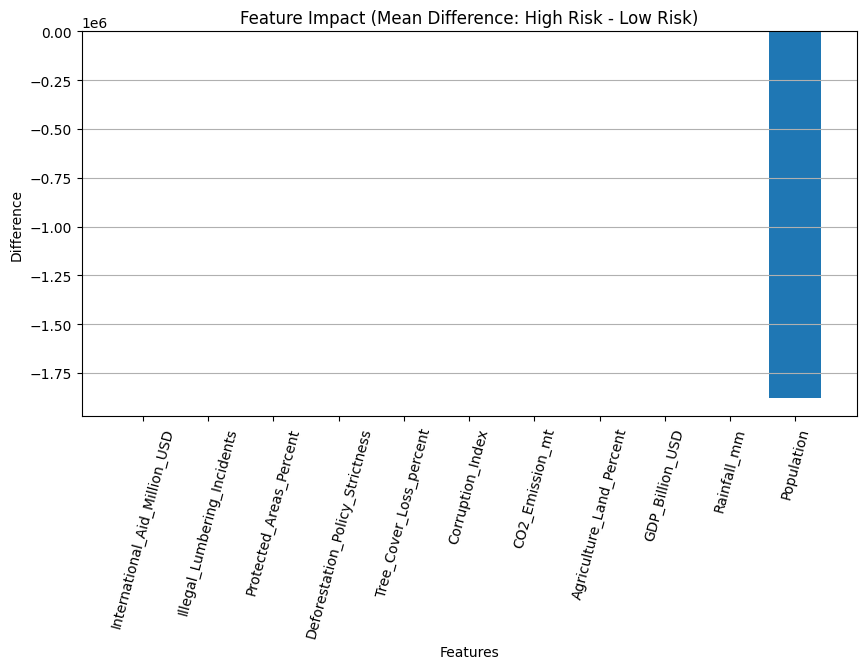

In [10]:
diff = risk_mean.loc["High Risk"] - risk_mean.loc["Low Risk"]
diff_sorted = diff.sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(diff_sorted.index, diff_sorted.values)
plt.title("Feature Impact (Mean Difference: High Risk - Low Risk)")
plt.xlabel("Features")
plt.ylabel("Difference")
plt.xticks(rotation=75)
plt.grid(True, axis="y")
plt.show()


In [11]:
X = df.drop(columns=["Deforestation_Risk", "Forest_Loss_Area_km2"])
y = df["Deforestation_Risk"]

categorical_cols = ["Country"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print(" Categorical Columns:", categorical_cols)
print(" Numerical Columns:", numerical_cols)


 Categorical Columns: ['Country']
 Numerical Columns: ['Year', 'Tree_Cover_Loss_percent', 'CO2_Emission_mt', 'Rainfall_mm', 'Population', 'GDP_Billion_USD', 'Agriculture_Land_Percent', 'Deforestation_Policy_Strictness', 'Corruption_Index', 'International_Aid_Million_USD', 'Illegal_Lumbering_Incidents', 'Protected_Areas_Percent']


In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (80, 13) (80,)
Test : (20, 13) (20,)


In [14]:
svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", probability=True, random_state=42))
])

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

print(" Baseline SVM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


 Baseline SVM Accuracy: 0.35
              precision    recall  f1-score   support

           0       0.29      0.20      0.24        10
           1       0.38      0.50      0.43        10

    accuracy                           0.35        20
   macro avg       0.34      0.35      0.34        20
weighted avg       0.34      0.35      0.34        20



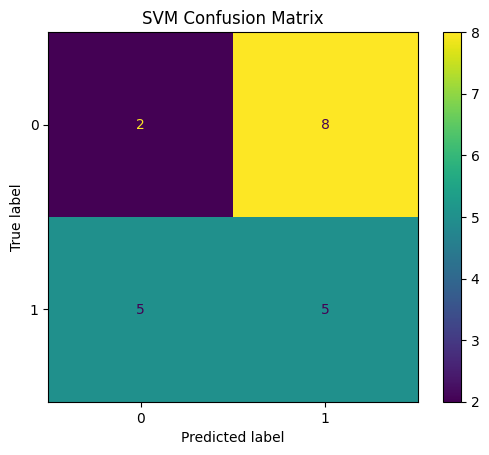

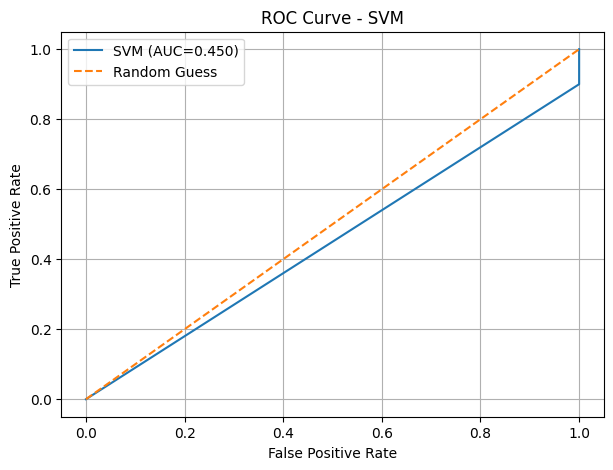

In [15]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("SVM Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"SVM (AUC={auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random Guess")
plt.title("ROC Curve - SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()


In [16]:
result = permutation_importance(
    svm_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance_Mean": result.importances_mean,
    "Importance_Std": result.importances_std
}).sort_values(by="Importance_Mean", ascending=False)

importance_df.head(15)


,Feature,Importance_Mean,Importance_Std
1,Year,8.000000e-02,0.040000
4,Rainfall_mm,6.000000e-02,0.037417
5,Population,3.500000e-02,0.039051
12,Protected_Areas_Percent,2.000000e-02,0.040000
7,Agriculture_Land_Percent,1.000000e-02,0.066332
0,Country,1.000000e-02,0.043589
10,International_Aid_Million_USD,-3.330669e-17,0.092195
3,CO2_Emission_mt,-5.000000e-03,0.041533
2,Tree_Cover_Loss_percent,-5.000000e-03,0.026926
6,GDP_Billion_USD,-5.000000e-03,0.052202


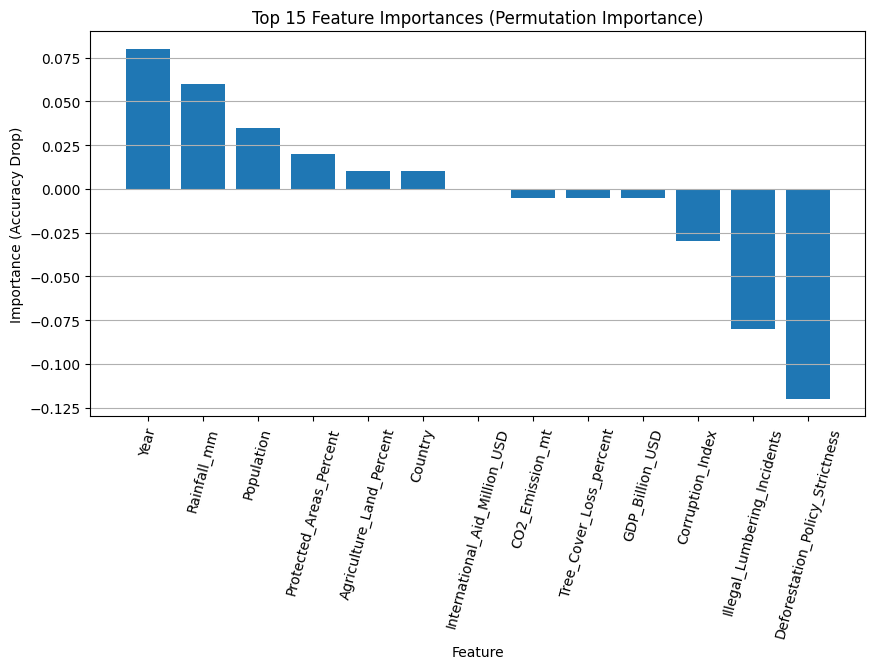

In [17]:
top_imp = importance_df.head(15)

plt.figure(figsize=(10,5))
plt.bar(top_imp["Feature"], top_imp["Importance_Mean"])
plt.title("Top 15 Feature Importances (Permutation Importance)")
plt.xlabel("Feature")
plt.ylabel("Importance (Accuracy Drop)")
plt.xticks(rotation=75)
plt.grid(True, axis="y")
plt.show()


In [18]:
svm_linear = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="linear", probability=True, random_state=42))
])

svm_linear.fit(X_train, y_train)

print(" Linear SVM Test Accuracy:", accuracy_score(y_test, svm_linear.predict(X_test)))


 Linear SVM Test Accuracy: 0.5


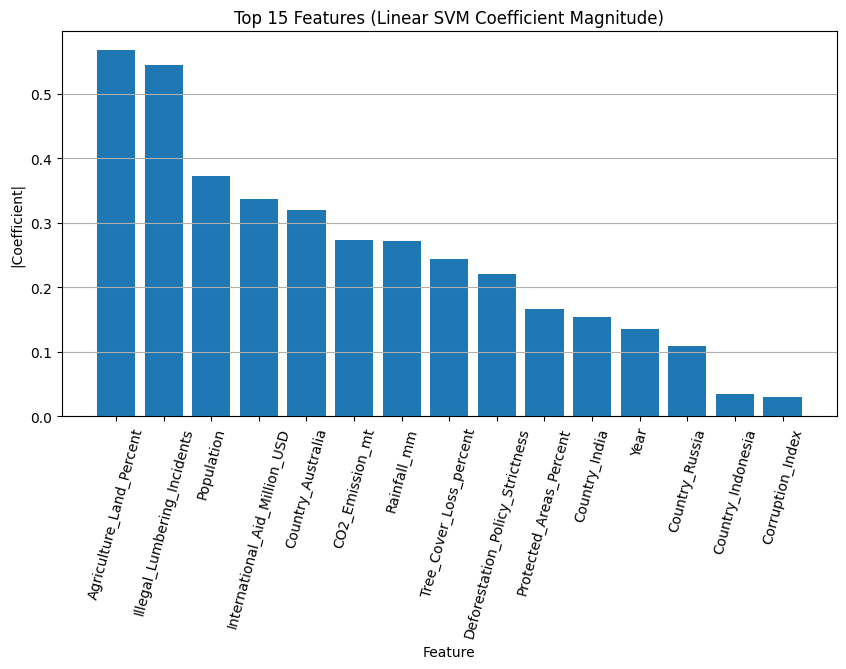

In [19]:
# Extract transformed feature names
ohe = svm_linear.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

all_feature_names = numerical_cols + list(cat_feature_names)

coef = svm_linear.named_steps["classifier"].coef_[0]
coef_abs = np.abs(coef)

coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Abs_Coefficient": coef_abs
}).sort_values(by="Abs_Coefficient", ascending=False)

coef_df.head(15)

top_coef = coef_df.head(15)

plt.figure(figsize=(10,5))
plt.bar(top_coef["Feature"], top_coef["Abs_Coefficient"])
plt.title("Top 15 Features (Linear SVM Coefficient Magnitude)")
plt.xlabel("Feature")
plt.ylabel("|Coefficient|")
plt.xticks(rotation=75)
plt.grid(True, axis="y")
plt.show()


In [20]:
country_risk = df.groupby("Country")["Deforestation_Risk"].mean().sort_values(ascending=False) * 100
country_risk = country_risk.reset_index()
country_risk.columns = ["Country", "High_Risk_%"]

country_risk.head(10)


,Country,High_Risk_%
0,Australia,60.000000
1,Brazil,52.173913
2,Russia,50.000000
3,India,46.666667
4,Indonesia,43.478261


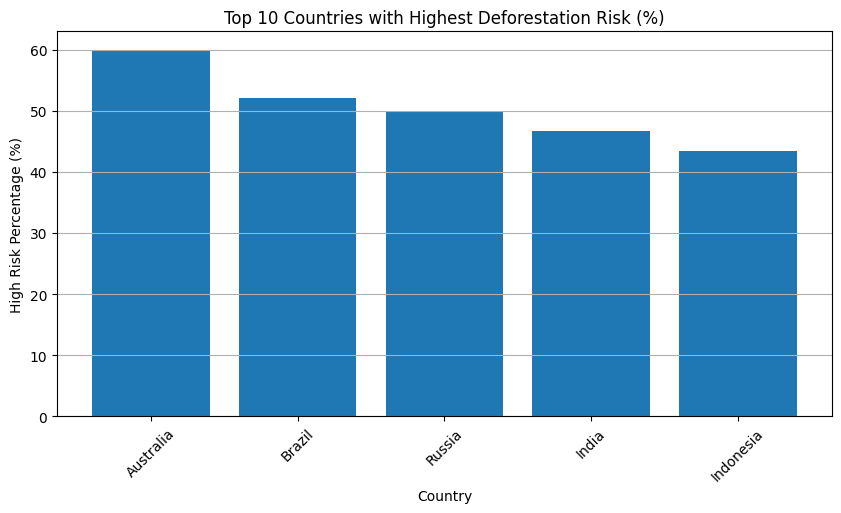

In [21]:
top10 = country_risk.head(10)

plt.figure(figsize=(10,5))
plt.bar(top10["Country"], top10["High_Risk_%"])
plt.title("Top 10 Countries with Highest Deforestation Risk (%)")
plt.xlabel("Country")
plt.ylabel("High Risk Percentage (%)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.show()


Summary 
Based on the model interpretation and feature importance analysis, I observed that deforestation risk is strongly influenced by factors such as illegal lumbering incidents, tree cover loss percentage, CO2 emissions, and land-use pressures (agriculture land percentage). To reduce deforestation risk, governments should strengthen enforcement against illegal logging, increase monitoring in high-risk regions, and improve forest protection through larger protected-area coverage. Policies should focus on balancing agriculture expansion with sustainable land practices and incentivizing reforestation programs. Countries with the highest predicted risk should be prioritized for stricter policy implementation, international environmental funding allocation, and long-term biodiversity protection efforts.